In [1]:
import Agents
import MarketsV03 as Markets

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

In [2]:
epsilon = 0.005
theta = 0.1

NA = 50
NB = 50
N = NA+NB

initialize_money = 'random'
M = 100.

n = 2

QA1 = 0.
QA2 = 0.

qA1 = 10.
qA2 = 0.

cA1 = 1.
cA2 = 1.

QB1 = 0.
QB2 = 0.

qB1 = 0.
qB2 = 5.

cB1 = 1.
cB2 = 1.

QA_0 = np.array([QA1, QA2])
QB_0 = np.array([QB1, QB2])

QA = np.copy(QA_0)
QB = np.copy(QB_0)

qA = np.array([qA1, qA2])
qB = np.array([qB1, qB2])

cA = np.array([cA1, cA2])
cB = np.array([cB1, cB2])

DA = cA.copy()
DB = cB.copy()

initialize_prices = 'random'

p1buy_A_0    = 0. 
p1sell_A_0   = 1.

p2buy_A_0    = 0.
p2sell_A_0   = 0. 

p1buy_B_0    = 1.
p1sell_B_0   = 0. 

p2buy_B_0    = 0.
p2sell_B_0   = 0.

In [3]:
def add_price_data(df, t):
    
    p_buy, p_sell = df
    
    for v, agent in enumerate(agent_list):
        p_buy[t][v] = agent.p_buy
        p_sell[t][v] = agent.p_sell
        
def add_quant_data(df, t):

    for v,agent in enumerate(agent_list):

        df[t][v] = agent.Q
    
def add_deficit_data(df, t):

    for v,agent in enumerate(agent_list):

        df[t][v] = agent.D
    
def add_money_data(df, t):
    
    for v,agent in enumerate(agent_list):

        df[t][v] = agent.M

In [4]:
def reset():
    
    for agent in agentA_list:
        
        if initialize_prices=='random':
            
            agent.p_buy  = np.random.uniform(agent.M, size=n)
            agent.p_sell = np.random.uniform(agent.M, size=n)
            
        else:
            agent.p_buy  = [p1buy_A_0, p2buy_A_0]
            agent.p_sell = [p1sell_A_0, p2sell_A_0]
        
    for agent in agentB_list:
        
        if initialize_prices=='random':
            agent.p_buy  = np.random.uniform(agent.M, size=n)
            agent.p_sell = np.random.uniform(agent.M, size=n)
        
        else:
            agent.p_buy  = [p1buy_B_0, p2buy_B_0]
            agent.p_sell = [p1sell_B_0, p2sell_B_0]
            
def market_supply_demand(i):
    supply0 = 0
    demand0 = 0
    for agent in agent_list:

        quants = scda.determine_market_quantity(agent)

        if quants[i] > 0:
            supply0 += quants[i]
        elif quants[i] < 0:
            demand0 += -quants[i]
            
    return supply0, demand0

In [5]:
agentA_list = [Agents.Agent(QA.copy(), DA.copy(), M, n_actions=1, input_dims=[1]) for v in range(NA)]
agentB_list = [Agents.Agent(QB.copy(), DB.copy(), M, n_actions=1, input_dims=[1]) for v in range(NB)]

agent_list = agentA_list + agentB_list

In [6]:
M_dict = {}

for agent in agent_list:
    
    M_dict[agent] = np.random.uniform(M)

In [7]:
M_total = 0
for agent in agent_list:
    M_total += agent.M
    
M_total

10000.0

In [8]:
# Initialize agent asking and bidding prices

In [9]:
max_tries = 100 #3 #1*N #1

In [10]:
scda = Markets.SCDA(n, theta=theta, gamma=1.0, epsilon=0.01, max_tries=max_tries, M_min=0.01, peval='log_mean')
ExchangeDict = {agent : 2 for agent in agent_list}

In [11]:
def randomize_prices():

    for agent in agent_list:

        if random.random() < epsilon:
            agent.p_buy = np.random.uniform(0, agent.M, n)

        if random.random() < epsilon:
            agent.p_sell = np.random.uniform(0, agent.M, n)

In [12]:
T = 10_000

reset()

# Setup data
p_buy, p_sell = np.zeros((T, N, n)), np.zeros((T, N, n))
p_df = (p_buy, p_sell)

Q_df = np.zeros((T, N, n))
D_df = np.zeros((T, N, n))
M_df = np.zeros((T, N))

# Setup data
ME_df = np.zeros((T-1,n))
QE_df = np.zeros((T-1,n))
ntries_df = []
    
supply_df = []
demand_df = []

add_price_data(p_df, 0)
add_quant_data(Q_df, 0)
add_deficit_data(D_df, 0)
add_money_data(M_df, 0)

Q__ = QA.copy()

# Run market
for t in range(T-1):
    
    if t % 100 == 0:
        print(t)

    supply0_t, demand0_t = market_supply_demand(0)
    supply1_t, demand1_t = market_supply_demand(1)
    
    supply_t = [supply0_t, supply1_t]
    demand_t = [demand0_t, demand1_t]

    # Market action occurs at half-time interval
    ME, QE, ntries = scda.run_exchange(ExchangeDict)

    # Reset quantities
    for agentA in agentA_list:
        
        c_t = np.minimum(agentA.Q, agentA.D)

        agentA.D = agentA.D + (cA - c_t)
        agentA.Q = np.maximum(0, agentA.Q + qA - c_t)
        

    for agentB in agentB_list:
        
        c_t = np.minimum(agentB.Q, agentB.D)

        agentB.D = agentB.D + (cB - c_t)
        agentB.Q = np.maximum(0, agentB.Q + qB - c_t)
        
    add_price_data(p_df, t+1)
    add_quant_data(Q_df, t+1)
    add_deficit_data(D_df, t)
    add_money_data(M_df, t)

    # Market action occurs at half-time interval
    ME_df[t] = ME
    QE_df[t] = QE
    ntries_df.append(ntries)

    supply_df.append(supply_t)
    demand_df.append(demand_t)
    
    randomize_prices()

p = ME_df/QE_df

supply_df = np.array(supply_df)
demand_df = np.array(demand_df)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900


C:\Users\Alex\AppData\Local\Temp\ipykernel_12012\2591794068.py:74: RuntimeWarning: invalid value encountered in divide
  p = ME_df/QE_df


In [13]:
'''
self = scda
i = 0

agent_data_i = self.agent_data[:,:,i]

# Create mask for buyers and select their data
# Eligible buyers have a negative surplus, and have money to spend
self.buyers_mask = (agent_data_i[:, 2] < 0) & (self.agent_Mdata > self.M_min)
buyers_data_i = agent_data_i[self.buyers_mask]

# Creat mask for sellers and select their data
self.sellers_mask = agent_data_i[:, 2] > 0
sellers_data_i = agent_data_i[self.sellers_mask]

N_buyers  = self.buyers_mask.sum()
N_sellers = self.sellers_mask.sum()

#self.buyers_transact[:]  = False #  = np.zeros(self.Nm, dtype=bool) # Length of all in transaction, not jus length of buyers
#self.sellers_transact[:] = False # = np.zeros(self.Nm, dtype=bool)
self.buyers_efficiencies[:] = 0.0
self.sellers_efficiencies[:] = 0.0
'''

'\nself = scda\ni = 0\n\nagent_data_i = self.agent_data[:,:,i]\n\n# Create mask for buyers and select their data\n# Eligible buyers have a negative surplus, and have money to spend\nself.buyers_mask = (agent_data_i[:, 2] < 0) & (self.agent_Mdata > self.M_min)\nbuyers_data_i = agent_data_i[self.buyers_mask]\n\n# Creat mask for sellers and select their data\nself.sellers_mask = agent_data_i[:, 2] > 0\nsellers_data_i = agent_data_i[self.sellers_mask]\n\nN_buyers  = self.buyers_mask.sum()\nN_sellers = self.sellers_mask.sum()\n\n#self.buyers_transact[:]  = False #  = np.zeros(self.Nm, dtype=bool) # Length of all in transaction, not jus length of buyers\n#self.sellers_transact[:] = False # = np.zeros(self.Nm, dtype=bool)\nself.buyers_efficiencies[:] = 0.0\nself.sellers_efficiencies[:] = 0.0\n'

In [14]:
'''
from scipy.special import softmax

N_transacting_agents = min(N_buyers, N_sellers)

# Using the bidding and asking prices, select a buyer, seller pair for this trial
# The buyers, sellers are selected with probabilities related to their prices. Use softmax for this
bidding_prices_i = buyers_data_i[:,0]
asking_prices_i  = sellers_data_i[:,1]

# Adjust the bids and asks
adjusted_bids = bidding_prices_i - np.max(bidding_prices_i)
adjusted_asks = asking_prices_i - np.min(asking_prices_i)

# Normalize the adjusted bids and asks to be in the range [0, 1]
range_bids = np.max(adjusted_bids) - np.min(adjusted_bids)
range_asks = np.max(adjusted_asks) - np.min(adjusted_asks)

normalized_bids = (adjusted_bids - np.min(adjusted_bids)) / max(range_bids, 1e-10)  # Avoid division by zero
normalized_asks = (adjusted_asks - np.min(adjusted_asks)) / max(range_asks, 1e-10)  # Avoid division by zero

# Apply softmax to the normalized values
softmax_bids = softmax(normalized_bids)
softmax_asks = softmax(-normalized_asks)            
'''

'\nfrom scipy.special import softmax\n\nN_transacting_agents = min(N_buyers, N_sellers)\n\n# Using the bidding and asking prices, select a buyer, seller pair for this trial\n# The buyers, sellers are selected with probabilities related to their prices. Use softmax for this\nbidding_prices_i = buyers_data_i[:,0]\nasking_prices_i  = sellers_data_i[:,1]\n\n# Adjust the bids and asks\nadjusted_bids = bidding_prices_i - np.max(bidding_prices_i)\nadjusted_asks = asking_prices_i - np.min(asking_prices_i)\n\n# Normalize the adjusted bids and asks to be in the range [0, 1]\nrange_bids = np.max(adjusted_bids) - np.min(adjusted_bids)\nrange_asks = np.max(adjusted_asks) - np.min(adjusted_asks)\n\nnormalized_bids = (adjusted_bids - np.min(adjusted_bids)) / max(range_bids, 1e-10)  # Avoid division by zero\nnormalized_asks = (adjusted_asks - np.min(adjusted_asks)) / max(range_asks, 1e-10)  # Avoid division by zero\n\n# Apply softmax to the normalized values\nsoftmax_bids = softmax(normalized_bids)\ns

Plotting

In [15]:
np.nanmean(p, axis=0)

array([0.22642434, 0.22699226])

In [16]:
def plot_market(i, *, ps=10, log=False, supply_demand=False, show_M_total=False, lw=0.5):

    f, ax = plt.subplots(1, figsize=(10,4)) #(2,1)

    ax.plot(ME_df[:,i], c='C0', label=f'$\Delta M_{i}$', lw=lw)
    ax.plot(QE_df[:,i], c='C1', label=f'$\Delta Q_{i}$', lw=lw)
    ax.plot(ntries_df, c='k', label='Tries', lw=lw)

    #ax.scatter(np.arange(0,T-1), p[:,i], c='g', label=f'$p_{i}$', s=ps)
    ax.plot(p[:,i], c='g', label=f'$p_{i}$', lw=lw)
    
    if supply_demand:
        ax.plot(supply_df[:,i], c='blue', ls='--', label=f'Supply', lw=lw)
        ax.plot(demand_df[:,i], c='orange', ls='--', label=f'Demand', lw=lw)
        
    if show_M_total:
        ax.axhline(M_total, c='g', ls=':', label='$M_{total}$', lw=lw)

    ax.legend(bbox_to_anchor=(1, 0.5))
    
    if log:
        plt.yscale('log')
        
    plt.title(f'Market for Commodity {i}')
    plt.xlabel('t')
    plt.ylabel('$M$, $Q$')

In [17]:
def plot_prices(i, *, log=False, lw=0.5):

    p_buy, p_sell = p_df[0], p_df[1]


    for n in range(NA):
        plt.plot(p_sell[:,n][:,i], c='C1', lw=lw/5.)
    plt.plot(M_df[:-1, 0:NA].sum(axis=1), c='g', ls='-', label='Sellers M', lw=lw)

    for n in range(NB):
        plt.plot(p_buy[:,NA+n][:,i], c='C0', lw=lw/5.)
    plt.plot(M_df[:-1, NA:].sum(axis=1), c='lime', ls='-', label='Buyers M', lw=lw)

    plt.plot(p[:,i], c='g', lw=lw)
    plt.ylim(ymin=0.007)

    plt.title(f'Commodity {i}. Blue Bidding Price. Orange Asking Price')
    if log:
        plt.yscale('log')

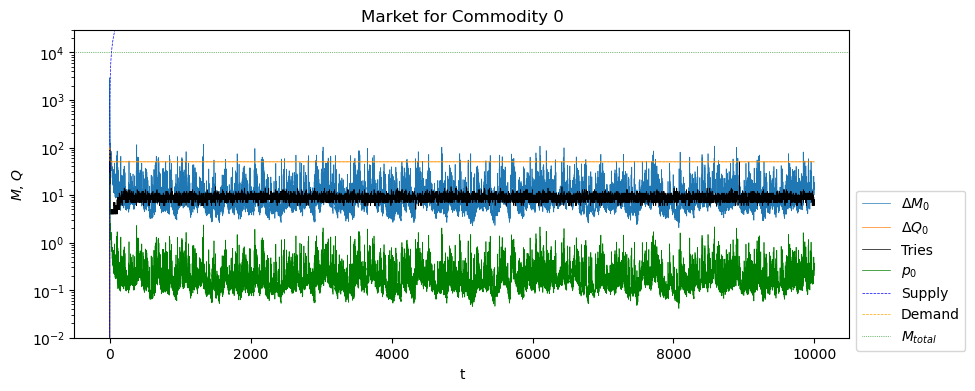

In [18]:
plot_market(0, log=True, supply_demand=True, show_M_total=True, lw=0.5)
plt.ylim(ymin=1e-2, ymax=3e4)
plt.show()

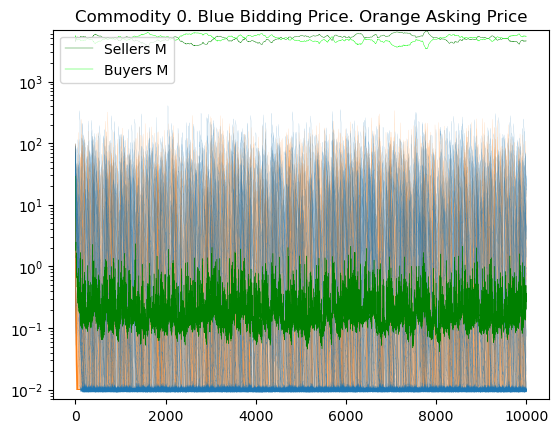

In [19]:
plot_prices(0, log=True, lw=0.3)
plt.legend()

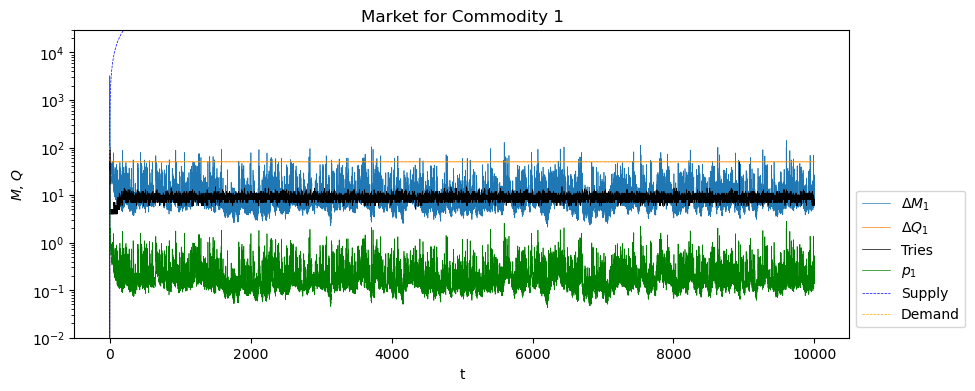

In [20]:
plot_market(1, log=True, supply_demand=True, show_M_total=False)
plt.ylim(ymin=1e-2, ymax=3e4)
plt.show()

(0.01, 30000.0)

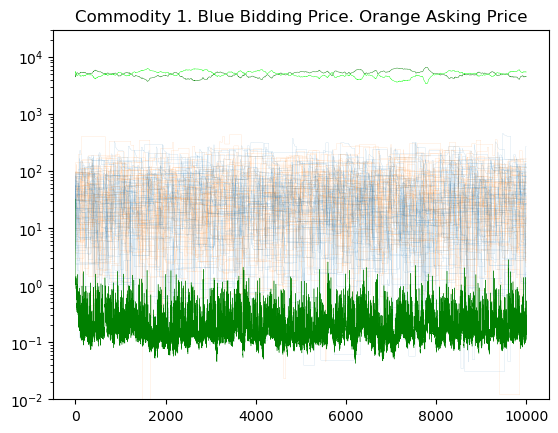

In [21]:
plot_prices(1, log=True, lw=0.3)
plt.ylim(ymin=1e-2, ymax=3e4)

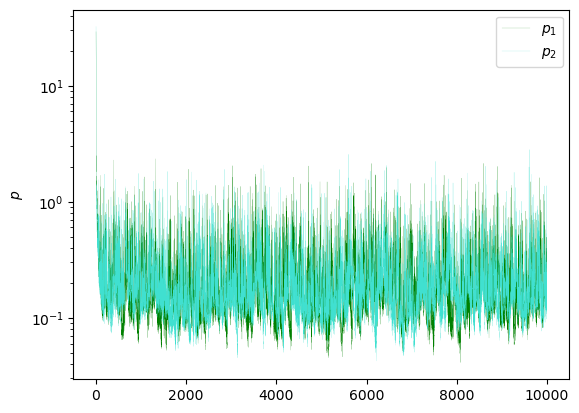

In [22]:
plt.plot(p[:,0], c='g', label='$p_1$', lw=0.1)
plt.plot(p[:,1], c='turquoise', label='$p_2$', lw=0.1)
plt.ylabel('$p$')
plt.yscale('log')
plt.legend()

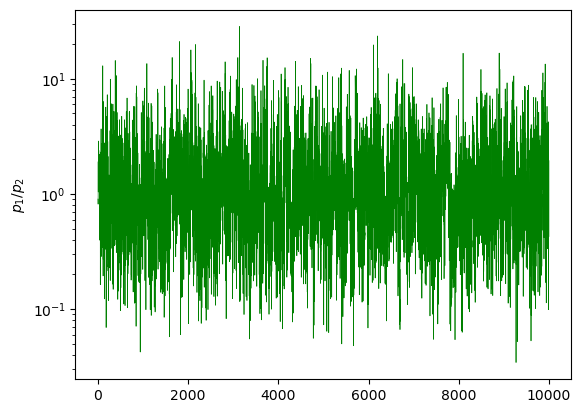

In [23]:
plt.plot(p[:,0]/p[:,1], c='g', lw=0.5)
plt.ylabel('$p_{1}/p_{2}$')
plt.yscale('log')

In [24]:
start = 1000
np.nanmean(p[start:,0]/p[start:,1])

1.4802122356475682

In [25]:
qB[1]/qA[0]

0.5

(array([  18.,  129.,  523., 1450., 2896., 2885., 1439.,  519.,  126.,
          13.]),
 array([-1.46325657, -1.17148236, -0.87970815, -0.58793394, -0.29615973,
        -0.00438552,  0.28738869,  0.5791629 ,  0.87093712,  1.16271133,
         1.45448554]),
 [<matplotlib.patches.Polygon at 0x232d101c850>])

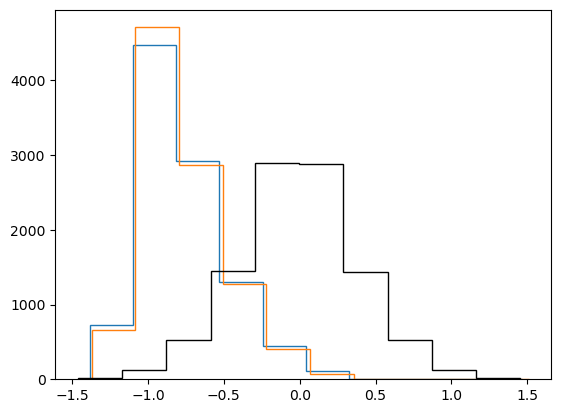

In [26]:
plt.hist(np.log10(p[:,0]), color='C0', histtype='step')
plt.hist(np.log10(p[:,1]), color='C1', histtype='step')
plt.hist(np.log10(p[:,0]/p[:,1]), color='k', histtype='step')

In [27]:
assert False

AssertionError: 

In [ ]:
#ME_df

In [ ]:
#QE_df

In [ ]:
x_data=[]
xx_data=[]

B = 10000

theta = 0.01

x = 1

for _ in range(B):
    

    th = np.random.choice([-theta, theta])
    
    x *= (1+th)
    x_data.append(x)
    
    theta2 = theta #theta/(1+theta)
    
    xx = (1+theta)**_ * (1-theta2)**_
    
    xx_data.append(xx)

x_data=np.array(x_data)
xx_data=np.array(xx_data)


In [ ]:
xx

In [ ]:
plt.plot(x_data)

In [ ]:
plt.plot(xx_data)



In [ ]:
def randomize_agent_bid(agent, i):
    
    #new_bid = np.random.uniform(M_min, agent.M)
    new_bid = random_bid_list[eps_agent_list < epsilon]
    agent.p_buy[i] = new_bid
    
def randomize_agent_ask(agent, i):
    
    new_ask = np.random.uniform(M_min, agent.M)
    agent.p_sell[i] = new_ask
    
epsilon = 1e-2
eps_agent_list = np.random.uniform(0,1, Nm)

    
bid_dist_i = agent_data[:, 0, i]

mean_bid = bid_dist_i.mean()
std_bid = bid_dist_i.std()

random_bid_list = std_bid/2.*np.random.standard_cauchy(Nm) + mean_bid

[randomize_agent_bid(agent, i) for agent in exchanging_agent_list[eps_agent_list < epsilon]]